In [1]:
!uv pip install -q --system numba-cuda==0.4.0

In [2]:
import numba.cuda as cuda
from numba import config
config.CUDA_ENABLE_PYNVJITLINK = 1
import matplotlib.pyplot as plt
import numpy as np
import time

Original

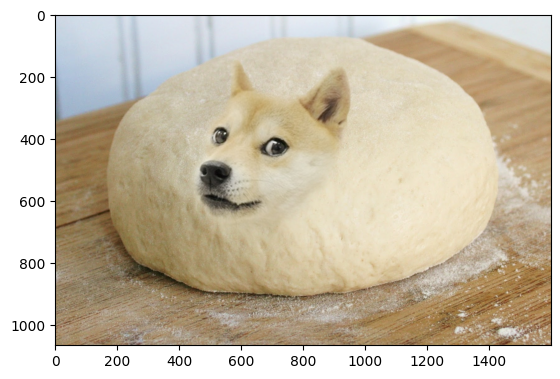

In [3]:
img_path = "/content/Doge.jpg"
img = plt.imread(img_path)
img_2D = img.astype(np.uint8)
plt.imshow(img)

Flatten

In [4]:
height, width, channels = img.shape
pixel_count = height * width
print(f"Image shape: {img.shape}, Total pixels: {pixel_count}")
img_1D = img.reshape(pixel_count, 3).astype(np.uint8)
print(f"Image shape after flatten: {img_1D.shape}")

Image shape: (1065, 1600, 3), Total pixels: 1704000
Image shape after flatten: (1704000, 3)


Grayscale 1D GPU

GPU time for block size 256: 0.8747 seconds


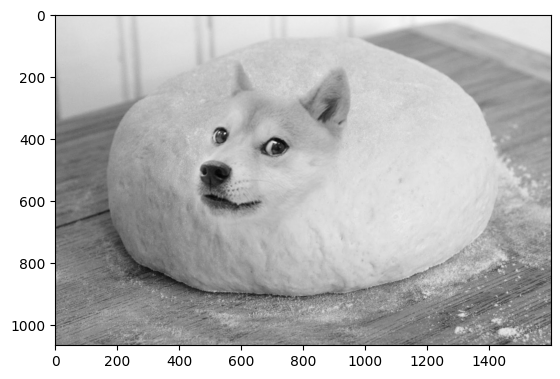

In [5]:
@cuda.jit
def grayscale_gpu(src, dst):
# where are we in the input?
  tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
  g = np.uint8((src[tidx, 0] + src[tidx, 1] + src[tidx, 2]) / 3)
  dst[tidx, 0] = dst[tidx, 1] = dst[tidx, 2] = g

d_src = cuda.to_device(img_1D)
d_dst = cuda.device_array((pixel_count, 3), dtype=np.uint8)
block_size = 256
grid_size = (pixel_count + (block_size - 1)) // block_size

start = time.time()
grayscale_gpu[grid_size, block_size](d_src, d_dst)
cuda.synchronize()
gpu1D_time = time.time() - start
print(f"GPU time for block size {block_size}: {gpu1D_time:.4f} seconds")

gray_gpu = d_dst.copy_to_host()
gray_gpu_image = gray_gpu[:, 0].reshape(height, width)
plt.imshow(gray_gpu_image, cmap='gray')

Grayscale 2D GPU

In [6]:
@cuda.jit
def grayscale2D(rgb_array, gray_array):
    x, y = cuda.grid(2)
    if x < rgb_array.shape[0] and y < rgb_array.shape[1]:
        idx = x * rgb_array.shape[1] + y
        r, g, b = rgb_array[x, y]
        gray_array[x, y] = 0.2989 * r + 0.5870 * g + 0.1140 * b

def run_grayscale2D(img, block_size):
    d_img = cuda.to_device(img)
    d_gray = cuda.device_array((height, width), dtype=np.uint8)

    grid_size_x = (width + block_size[0] - 1) // block_size[0]
    grid_size_y = (height + block_size[1] - 1) // block_size[1]
    grid_size = (grid_size_x, grid_size_y)

    start_time = time.time()
    grayscale2D[grid_size, block_size](d_img, d_gray)
    cuda.synchronize()
    end_time = time.time()

    gray_image = d_gray.copy_to_host()
    return gray_image, end_time - start_time


Execution time vs speedup:
(4, 4) (16 threads): 0.195312 sec, Speedup: 4.48x
(8, 8) (64 threads): 0.000393 sec, Speedup: 2226.20x
(16, 8) (128 threads): 0.000371 sec, Speedup: 2360.86x
(16, 16) (256 threads): 0.000369 sec, Speedup: 2371.54x
(32, 16) (512 threads): 0.000496 sec, Speedup: 1764.68x
(32, 32) (1024 threads): 0.000519 sec, Speedup: 1684.47x


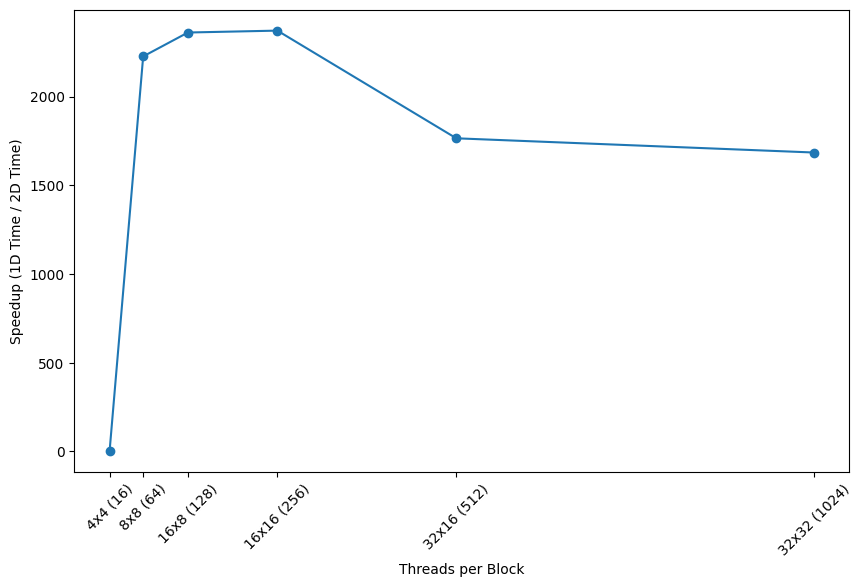

In [7]:
block_sizes = [(4, 4), (8, 8), (16, 8), (16, 16), (32, 16), (32, 32)]
results = {}

for block_size in block_sizes:
    gray_image, exec_time = run_grayscale2D(img, block_size)
    results[block_size] = exec_time

block_size = [bs[0] * bs[1] for bs in block_sizes]
speedups = [gpu1D_time / results[bs] for bs in block_sizes]

print("\nExecution time vs speedup:")
for bs, threads, exec_time in zip(block_sizes, block_size, [results[bs] for bs in block_sizes]):
    speedup = gpu1D_time / exec_time
    print(f"{bs} ({threads} threads): {exec_time:.6f} sec, Speedup: {speedup:.2f}x")

plt.figure(figsize=(10, 6))
plt.plot(block_size, speedups, marker='o')
plt.xlabel('Threads per Block')
plt.ylabel('Speedup (1D Time / 2D Time)')
plt.xticks(block_size, [f"{bs[0]}x{bs[1]} ({t})" for bs, t in zip(block_sizes, block_size)], rotation=45)
plt.show()